In [1]:
# 颜色、标签和样式配置
colors_1 = ['#0d21a1', '#2196f3','#a51c30', '#c52233']  # 第一组颜色
colors_2 = ['#7b2cbf', '#c77dff']  # 第二组颜色


# 数据来自 test2_init 和
# mmca_init_eta_repeat_out文件夹

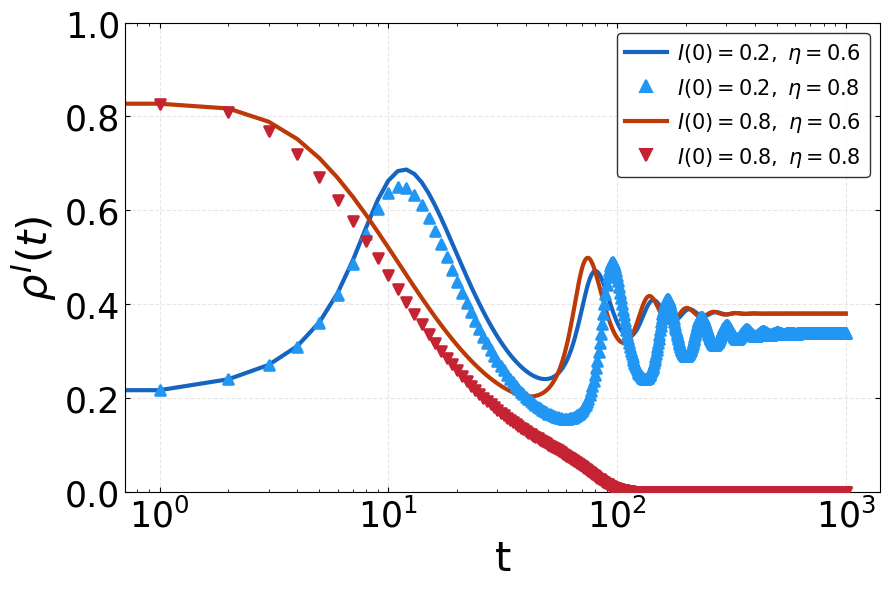

In [2]:
#!/usr/bin/env python3
# plot_mmca_init_eta_curves.py

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ===================== User Config =====================
DATA_DIR = "mmca_init_eta_repeat_out"

# 所有数据对
pairs = [
    (0.20, 0.60),  # 直线1
    (0.20, 0.80),  # 散点1
    (0.80, 0.60),  # 直线2
    (0.80, 0.80)   # 散点2
]

# 颜色配置
colors = ['#1565c0', '#2196f3', '#bc3908', '#c52233']

# 标签配置
labels = [fr'$I(0)={i}, \  \eta={e}$' for (i,e) in pairs]

# 样式配置：交替使用直线和散点
plot_types = ['line', 'scatter', 'line', 'scatter']  # 定义每条线的类型
linestyles = ['-', '', '-', '']  # 散点图不需要线型
markers = ['', '^', '', 'v']     # 直线不需要标记，散点需要
# ========================================================

# ---------- Load data ----------
dfs = []
for (init, eta) in pairs:
    fn = os.path.join(DATA_DIR, f"init{init:.2f}_eta{eta:.2f}_avg.csv")
    df = pd.read_csv(fn)
    dfs.append(df)

# ---------- Plot rho(t) ----------
plt.figure(figsize=(9,6))

# 存储图例句柄和标签
legend_handles = []
legend_labels = []

# 按顺序绘制所有曲线
for i, (df, lab, col, plot_type, ls, marker) in enumerate(zip(dfs, labels, colors, plot_types, linestyles, markers)):
    time = df["time"].values
    rho = df["rho"].values
    
    # 创建自定义索引
    # idx_before_100 = np.where(time <= 100)[0]
    # idx_after_100 = np.where(time > 100)[0]
    # if len(idx_after_100) > 0:
    #     idx_after_100_sampled = idx_after_100[::15]
    #     if len(idx_after_100_sampled) == 0:
    #         idx_after_100_sampled = [idx_after_100[-1]]
    # else:
    #     idx_after_100_sampled = []
    
    # indices = list(idx_before_100) + list(idx_after_100_sampled)
    
    if plot_type == 'line':
        # 绘制线条
        line = plt.plot(time, rho, 
                       linestyle=ls, 
                       label=lab, 
                       linewidth=3, 
                       color=col)[0]
        legend_handles.append(line)
        
    else:  # scatter
        # 绘制散点
        scatter = plt.scatter(#time[indices], rho[indices],
                             time, rho,
                             marker=marker,
                             s=50,
                             facecolor=col,
                             edgecolor=col,
                             linewidth=2,
                             label=lab,
                             zorder=3)
        # 创建散点的图例句柄
        scatter_handle = Line2D([0], [0], 
                               marker=marker, 
                               color='w', 
                               markerfacecolor=col,
                               markeredgecolor=col,
                               markersize=8,
                               markeredgewidth=1.5)
        legend_handles.append(scatter_handle)
    
    legend_labels.append(lab)

plt.xlabel("t", fontsize=30)
plt.ylabel("$\\rho^I(t)$", fontsize=30)
plt.xscale("log")
plt.yscale("linear")
plt.yticks(fontsize=25)
plt.ylim(0, 1)
plt.xticks(fontsize=25)

# 使用自定义的图例句柄和标签创建图例
legend = plt.legend(legend_handles, legend_labels,
                   loc='upper right',
                   fontsize=15,
                   handletextpad=0.5,
                   borderpad=0.4,
                   handlelength=2.0,
                   )

legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1)

plt.tick_params(
    axis='both',
    which='both',
    top=True,
    right=True,
    labeltop=False,
    labelright=False,
    direction='in',
)

plt.grid(alpha=0.3, linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('test2_1.pdf', bbox_inches='tight', dpi=300)
plt.show()

正在读取: mmca_heatmap_init0.2_parallel\heatmap_mean_ss_rho_init0.2.csv


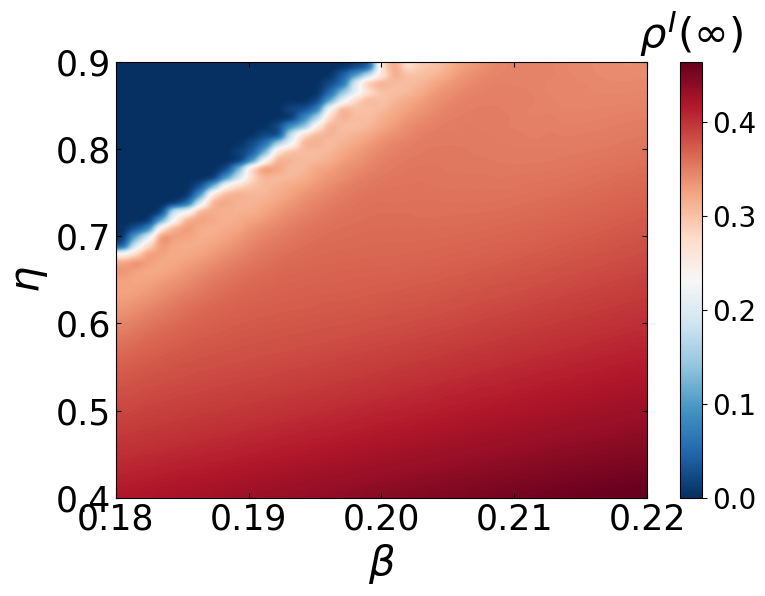

保存热力图到: ./heatmap_mean_ss_rho_init0.2.pdf
正在读取: mmca_heatmap_init0.8_parallel\heatmap_mean_ss_rho_init0.8.csv


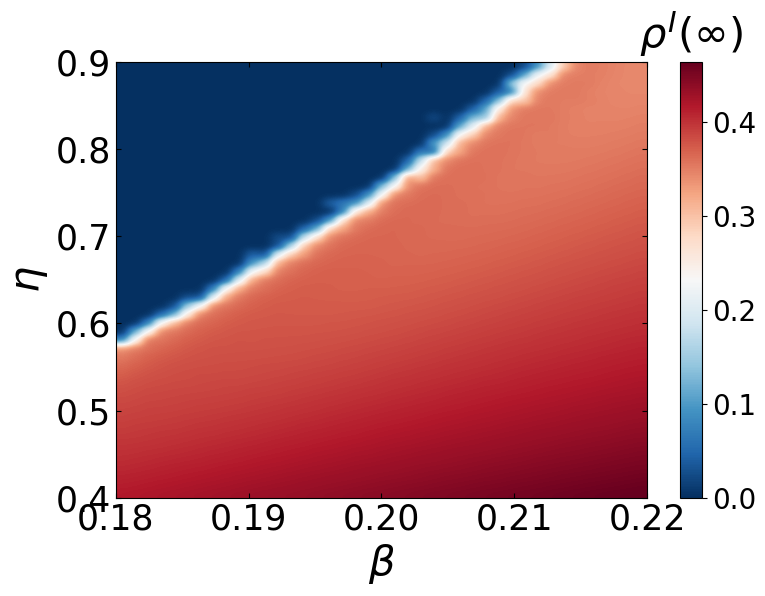

保存热力图到: ./heatmap_mean_ss_rho_init0.8.pdf

所有热力图生成完成!


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------- 从CSV文件读取数据并绘制热力图 ---------------------

# 定义初始感染率列表
init_fracs = [0.2, 0.8]

# 网格参数（需要与生成CSV文件时使用的参数一致）
beta_min, beta_max = 0.18, 0.22
eta_min, eta_max = 0.3, 0.8

for init_frac in init_fracs:
    # 构建CSV文件路径
    out_dir = f"mmca_heatmap_init{init_frac}_parallel"
    csv_fn = os.path.join(out_dir, f"heatmap_mean_ss_rho_init{init_frac}.csv")
    
    # 检查文件是否存在
    if not os.path.exists(csv_fn):
        print(f"警告: 文件 {csv_fn} 不存在，跳过 init_frac = {init_frac}")
        continue
    
    print(f"正在读取: {csv_fn}")
    
    # 读取CSV文件
    df_heat = pd.read_csv(csv_fn, index_col=0)
    
    # 提取热力矩阵数据
    heatmat = df_heat.values
    
    # 从索引和列名中提取eta和beta的值
    etas = df_heat.index.values.astype(float)
    betas = df_heat.columns.values.astype(float)
    
    # 画热力图
    plt.figure(figsize=(8,6))
    
    # 使用提取的eta和beta范围
    plt.imshow(heatmat, origin='lower', aspect='auto', cmap='RdBu_r', interpolation='gaussian',
               extent=[betas.min(), betas.max(), etas.min(), etas.max()])
    
    # 创建 colorbar 并设置标签及刻度字体大小
    colorbar = plt.colorbar(label='')
    colorbar.ax.tick_params(labelsize='20')
    # 移动 colorbar 标签到最上方
    colorbar.ax.set_title(r'$\rho^I \left ( \infty \right ) $', fontsize=30, pad=10)
    
    # 设置 colorbar 的大小（高度）为原图的一半
    colorbar.ax.set_position([0.8, 0.12, 0.3, 0.75])
    
    plt.xlabel(r"$\beta$", fontsize=30)
    plt.ylabel(r"$\eta$", fontsize=30)
    
    # 美化坐标刻度：选几个刻度显示
    plt.xticks(np.linspace(betas.min(), betas.max(), 5), fontsize=25)
    plt.yticks(np.linspace(etas.min(), etas.max(), 6), fontsize=25)

    # 启用四面刻度
    plt.tick_params(
        axis='both',      # 同时控制 x 和 y 轴
        which='both',     # 同时控制主刻度和次刻度
        top=True,         # 显示顶部刻度
        right=True,       # 显示右侧刻度
        labeltop=False,   # 不显示顶部刻度标签（避免重叠）
        labelright=False,  # 不显示右侧刻度标签（避免重叠）
        direction='in',   # 刻度朝内
    )

    
    pdf_fn = os.path.join("./", f"heatmap_mean_ss_rho_init{init_frac}.pdf")
    plt.tight_layout()
    plt.savefig(pdf_fn, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"保存热力图到: {pdf_fn}")

print("\n所有热力图生成完成!")